# Task 5 - Grad-CAM Comparison (ResNet50 vs VGG16 vs DenseNet121)

Loads the three already-trained Task 2 models (no retraining) and generates a class
activation map for **every one of the 130 test images, for every model**.

**Why Grad-CAM instead of classic CAM**: classic CAM needs the classifier to be
"global average pooling -> one Linear layer", so the Linear weights can be read off
directly as per-channel importance. ResNet50 and DenseNet121 have that structure, but
VGG16's classifier is three stacked fully-connected layers with no global average
pooling, so classic CAM is not defined for it. Grad-CAM replaces the Linear weights with
the **gradient of the target class score w.r.t. the last convolutional feature map,
averaged over the spatial positions** - for a GAP+Linear head this reproduces classic CAM
exactly, and it works for any CNN without touching the model. Using Grad-CAM on all three
keeps the comparison on one method.

**Target class**: the model's own *predicted* class - the map answers "which region made
this model output this answer", which is what we want for inspecting both correct and
wrong predictions.

**Target layer** (the last convolutional feature map before the classifier):

| Model | Layer | Feature map size |
|---|---|---|
| ResNet50 | output of `layer4` | 2048 x 7 x 7 |
| VGG16 | output of `features[29]` (ReLU after the last conv, before the last max-pool) | 512 x 14 x 14 |
| DenseNet121 | `relu(features(x))` (after `norm5` + the ReLU the classifier sees) | 1024 x 7 x 7 |

Note the resolution difference: VGG16's map is 14x14, the other two are 7x7, so VGG16's
heatmaps are inherently finer-grained after upsampling to 224x224. This is a property of
where each architecture's last conv layer sits, not something a fairer setting could remove.

**Objective check against the ground-truth lesion masks**: the BUSI dataset ships a
lesion segmentation mask for every image (`~/datasets/BUSI/labels/`). The masks were
never used for training; here they are only used to *measure* whether a CAM lands on
the lesion, so the written comparison does not rely on eyeballing alone.

## 1. Configuration and imports

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models

DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
IMAGES_ROOT = os.path.join(DATASET_DIR, "images")
MASKS_ROOT = os.path.join(DATASET_DIR, "labels")  # lesion masks - evaluation only
IMAGE_COL, LABEL_COL = "Image", "Label"
IMG_SIZE = 224
RANDOM_SEED = 42

PROJECT_DIR = os.path.expanduser("~/projects/research_training")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "task5_cam")

# Width of the "image border" band used to measure how much CAM sits on the edge of the
# frame (ultrasound images have text/rulers/black margins there): 10% of the side length.
BORDER_FRAC = 0.10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2. Load the test set and verify the label mapping

Same filename cross-check as every other notebook in this project.

In [2]:
train_df = pd.read_excel(TRAIN_XLSX)
test_df = pd.read_excel(TEST_XLSX)

combined_df = pd.concat([train_df, test_df], ignore_index=True)
name_from_file = combined_df[IMAGE_COL].astype(str).str.extract(r"^([A-Za-z]+)")[0].str.lower()
check_table = pd.crosstab(combined_df[LABEL_COL], name_from_file)

id_to_name = {}
for label_id, row in check_table.iterrows():
    matched_names = row[row > 0].index.tolist()
    assert len(matched_names) == 1
    id_to_name[int(label_id)] = matched_names[0]

CLASS_NAMES = [id_to_name[i] for i in sorted(id_to_name)]
print(check_table)
print("CLASS_NAMES:", CLASS_NAMES)
print(f"test set: {len(test_df)} images")
print(test_df[LABEL_COL].map(lambda i: CLASS_NAMES[i]).value_counts())

0      benign  malignant
Label                   
0           0        210
1         437          0
CLASS_NAMES: ['malignant', 'benign']
test set: 130 images
Label
benign       91
malignant    39
Name: count, dtype: int64


## 3. Preprocessing (identical to the Task 2 eval transform) and lesion masks

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def load_sample(idx):
    """Returns (normalized tensor, 224x224 RGB display image in [0,1], 224x224 bool mask, label, filename)."""
    row = test_df.iloc[idx]
    fname = str(row[IMAGE_COL])
    image = Image.open(os.path.join(IMAGES_ROOT, fname)).convert("RGB")
    tensor = eval_transform(image)
    display = np.asarray(image.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR), dtype=np.float32) / 255.0
    # Masks are palette PNGs with values {0, 1}; nearest-neighbour keeps them binary.
    mask = Image.open(os.path.join(MASKS_ROOT, fname)).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    mask = np.asarray(mask) > 0
    return tensor, display, mask, int(row[LABEL_COL]), fname


_, _, m0, _, f0 = load_sample(0)
print(f"example: {f0}, mask covers {m0.mean():.1%} of the image")

example: malignant (30).png, mask covers 26.2% of the image


## 4. Models and Grad-CAM

Each model is rebuilt exactly as its Task 2 notebook built it, then split into two
functions: `features(x)` up to the target layer, and `head(A)` from the target layer to
the logits. Grad-CAM for class c:

1. `A = features(x)` (shape K x h x w), `y = head(A)[c]`
2. `alpha_k = mean over (i, j) of dy/dA_k[i, j]`  (one weight per channel)
3. `cam = ReLU(sum_k alpha_k * A_k)`, upsampled bilinearly to 224x224 and divided by its max

Splitting the forward pass explicitly (instead of forward/backward hooks) avoids the
in-place ReLUs inside torchvision's VGG/DenseNet silently changing the hooked tensors.

In [4]:
def build_resnet50():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
    return model


def build_vgg16():
    model = models.vgg16(weights=None)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, len(CLASS_NAMES))
    return model


def build_densenet121():
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, len(CLASS_NAMES))
    return model


def resnet50_split(m):
    def features(x):
        x = m.maxpool(m.relu(m.bn1(m.conv1(x))))
        return m.layer4(m.layer3(m.layer2(m.layer1(x))))

    def head(a):
        return m.fc(torch.flatten(m.avgpool(a), 1))
    return features, head


def vgg16_split(m):
    def features(x):
        return m.features[:30](x)  # through the ReLU after the last conv (14x14)

    def head(a):
        a = m.features[30](a)  # last max-pool
        return m.classifier(torch.flatten(m.avgpool(a), 1))
    return features, head


def densenet121_split(m):
    def features(x):
        return F.relu(m.features(x))  # not in-place, so the tensor we differentiate w.r.t. stays intact

    def head(a):
        return m.classifier(torch.flatten(F.adaptive_avg_pool2d(a, (1, 1)), 1))
    return features, head


MODEL_SPECS = {
    "ResNet50": (build_resnet50, resnet50_split,
                 os.path.join(PROJECT_DIR, "task2_resnet_baseline/outputs/resnet50_model.pt"), "resnet50"),
    "VGG16": (build_vgg16, vgg16_split,
              os.path.join(PROJECT_DIR, "task2_vgg16/outputs/vgg16_model.pt"), "vgg16"),
    "DenseNet121": (build_densenet121, densenet121_split,
                    os.path.join(PROJECT_DIR, "task2_densenet121/outputs/densenet121_model.pt"), "densenet121"),
}


def grad_cam(features, head, x):
    """x: 1x3xHxW. Returns (224x224 cam in [0,1], softmax probs, predicted class, feature-map size)."""
    x = x.to(device)
    a = features(x)
    logits = head(a)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred = int(logits.argmax(dim=1).item())
    grads = torch.autograd.grad(logits[0, pred], a)[0]  # 1 x K x h x w
    weights = grads.mean(dim=(2, 3), keepdim=True)        # alpha_k
    cam = F.relu((weights * a).sum(dim=1, keepdim=True))  # 1 x 1 x h x w
    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)[0, 0]
    cam = cam.detach().cpu().numpy()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam, probs, pred, tuple(a.shape[2:])


# Sanity check: the split forward pass must reproduce each model's own forward() exactly.
x0 = load_sample(0)[0].unsqueeze(0).to(device)
for name, (builder, splitter, path, _) in MODEL_SPECS.items():
    m = builder()
    m.load_state_dict(torch.load(path, map_location=device))
    m = m.to(device).eval()
    feat, head = splitter(m)
    with torch.no_grad():
        diff = (m(x0) - head(feat(x0))).abs().max().item()
        fmap = tuple(feat(x0).shape[1:])
    print(f"{name}: split-vs-original max |logit diff| = {diff:.2e}, target feature map = {fmap}")
    assert diff < 1e-4

ResNet50: split-vs-original max |logit diff| = 0.00e+00, target feature map = (2048, 7, 7)


VGG16: split-vs-original max |logit diff| = 0.00e+00, target feature map = (512, 14, 14)
DenseNet121: split-vs-original max |logit diff| = 0.00e+00, target feature map = (1024, 7, 7)


## 5. Metrics used to describe each CAM

All computed on the 224x224 normalized CAM against the ground-truth lesion mask:

- **`lesion_energy`** = sum(CAM inside the lesion mask) / sum(CAM). The fraction of the
  map's total activation that lies on the lesion. Compare it with **`lesion_area`** (the
  fraction of the image the mask covers) - that is what a CAM spread uniformly over the
  image would score, i.e. the chance level.
- **`peak_in_lesion`** ("pointing game"): whether the single highest-activation pixel falls
  inside the lesion mask.
- **`border_energy`**: fraction of CAM in the outer 10% band of the frame (where
  ultrasound images carry black margins, rulers and text). The band is 36% of the image
  area, so a uniform map would score 0.36.
- **`hot_area`**: fraction of the image where CAM > 0.5 - how spread out / compact the map is.

In [5]:
b = int(round(BORDER_FRAC * IMG_SIZE))
BORDER_BAND = np.ones((IMG_SIZE, IMG_SIZE), dtype=bool)
BORDER_BAND[b:-b, b:-b] = False
print(f"border band: {b}px wide, covers {BORDER_BAND.mean():.1%} of the image")


def cam_metrics(cam, mask):
    total = cam.sum()
    if total == 0:
        return dict(lesion_energy=np.nan, peak_in_lesion=False, border_energy=np.nan, hot_area=0.0)
    peak = np.unravel_index(cam.argmax(), cam.shape)
    return dict(
        lesion_energy=float(cam[mask].sum() / total),
        peak_in_lesion=bool(mask[peak]),
        border_energy=float(cam[BORDER_BAND].sum() / total),
        hot_area=float((cam > 0.5).mean()),
    )

border band: 22px wide, covers 35.4% of the image


## 6. Generate Grad-CAM for all 130 test images, for each model

For every (model, image) pair one figure is saved to `task5_cam/<model>/`:
left = original image, right = CAM overlay; the ground-truth lesion outline is drawn in
green on both panels (reference only). Filenames carry the index, the image name, the
true/predicted class, and `OK`/`WRONG`, so misclassified cases are easy to find.
Per-image numbers go to `task5_cam/<model>/cam_stats.csv`.

In [6]:
def safe_stem(fname):
    return os.path.splitext(fname)[0].replace(" (", "_").replace(")", "").replace(" ", "_")


def draw_panels(ax_img, ax_cam, display, cam, mask):
    ax_img.imshow(display)
    ax_cam.imshow(display)
    ax_cam.imshow(cam, cmap="jet", alpha=0.45, vmin=0, vmax=1)
    for ax in (ax_img, ax_cam):
        ax.contour(mask, levels=[0.5], colors="lime", linewidths=1.0)
        ax.axis("off")


samples = [load_sample(i) for i in range(len(test_df))]
all_cams = {}   # model -> (N, 224, 224) float16, reused by the comparison figures below
all_stats = []

for name, (builder, splitter, path, tag) in MODEL_SPECS.items():
    model_dir = os.path.join(OUTPUT_DIR, tag)
    os.makedirs(model_dir, exist_ok=True)
    m = builder()
    m.load_state_dict(torch.load(path, map_location=device))
    m = m.to(device).eval()
    features, head = splitter(m)

    cams = np.zeros((len(samples), IMG_SIZE, IMG_SIZE), dtype=np.float16)
    rows = []
    for idx, (tensor, display, mask, label, fname) in enumerate(samples):
        cam, probs, pred, _ = grad_cam(features, head, tensor.unsqueeze(0))
        cams[idx] = cam
        correct = pred == label
        row = dict(model=name, idx=idx, image=fname, true=CLASS_NAMES[label], pred=CLASS_NAMES[pred],
                   correct=correct, prob_pred=float(probs[pred]),
                   prob_malignant=float(probs[CLASS_NAMES.index("malignant")]),
                   lesion_area=float(mask.mean()), **cam_metrics(cam, mask))
        rows.append(row)

        fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.4, 3.6))
        draw_panels(a1, a2, display, cam, mask)
        a1.set_title(f"{fname}\ntrue: {CLASS_NAMES[label]}", fontsize=9)
        a2.set_title(f"{name} Grad-CAM\npred: {CLASS_NAMES[pred]} (p={probs[pred]:.2f})",
                     fontsize=9, color=("green" if correct else "red"))
        fig.tight_layout()
        out = os.path.join(model_dir, f"{idx:03d}_{safe_stem(fname)}_true-{CLASS_NAMES[label]}"
                                      f"_pred-{CLASS_NAMES[pred]}_{'OK' if correct else 'WRONG'}.jpg")
        fig.savefig(out, dpi=100, pil_kwargs={"quality": 88})
        plt.close(fig)  # closed figures are not rendered inline - 390 of them would bloat the notebook

    all_cams[name] = cams
    stats_df = pd.DataFrame(rows)
    stats_df.to_csv(os.path.join(model_dir, "cam_stats.csv"), index=False, float_format="%.4f")
    all_stats.append(stats_df)
    print(f"{name}: {len(rows)} CAM figures -> {model_dir}  "
          f"(accuracy {stats_df.correct.mean():.4f}, {int((~stats_df.correct).sum())} wrong)")

stats = pd.concat(all_stats, ignore_index=True)

ResNet50: 130 CAM figures -> /mnt/cv_data/users/hahaxixi/projects/research_training/task5_cam/resnet50  (accuracy 0.9000, 13 wrong)


VGG16: 130 CAM figures -> /mnt/cv_data/users/hahaxixi/projects/research_training/task5_cam/vgg16  (accuracy 0.8615, 18 wrong)


DenseNet121: 130 CAM figures -> /mnt/cv_data/users/hahaxixi/projects/research_training/task5_cam/densenet121  (accuracy 0.9000, 13 wrong)


## 7. Summary statistics per model

Means over the 130 test images, split into correctly vs. wrongly classified. Chance
levels for reference: `lesion_energy` of a uniform map = mean `lesion_area`; `border_energy`
of a uniform map = 0.354.

In [7]:
pd.set_option("display.width", 160)
agg = dict(n=("idx", "size"), lesion_area=("lesion_area", "mean"), lesion_energy=("lesion_energy", "mean"),
           peak_in_lesion=("peak_in_lesion", "mean"), border_energy=("border_energy", "mean"),
           hot_area=("hot_area", "mean"))

overall = stats.groupby("model", sort=False).agg(**agg)
by_correct = stats.groupby(["model", "correct"], sort=False).agg(**agg)
by_class = stats.groupby(["model", "true"], sort=False).agg(**agg)
print("All 130 test images:")
print(overall.round(3))
print("\nSplit by correct / wrong prediction:")
print(by_correct.round(3))
print("\nSplit by true class:")
print(by_class.round(3))

summary = {
    "overall": overall.round(4).reset_index().to_dict(orient="records"),
    "by_correct": by_correct.round(4).reset_index().to_dict(orient="records"),
    "by_true_class": by_class.round(4).reset_index().to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "cam_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

All 130 test images:
               n  lesion_area  lesion_energy  peak_in_lesion  border_energy  hot_area
model                                                                                
ResNet50     130        0.097          0.274           0.385          0.047     0.060
VGG16        130        0.097          0.191           0.354          0.261     0.070
DenseNet121  130        0.097          0.195           0.508          0.208     0.213

Split by correct / wrong prediction:
                       n  lesion_area  lesion_energy  peak_in_lesion  border_energy  hot_area
model       correct                                                                          
ResNet50    True     117        0.092          0.270           0.385          0.042     0.058
            False     13        0.138          0.304           0.385          0.085     0.073
VGG16       True     112        0.091          0.199           0.366          0.257     0.069
            False     18        0.134    

In [8]:
# How similar are the three models' maps on the same image? Pearson correlation of the
# 224x224 CAMs, averaged over the 130 images, for each pair of models.
names = list(MODEL_SPECS)
pair_corr = {}
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a = all_cams[names[i]].reshape(len(samples), -1).astype(np.float32)
        c = all_cams[names[j]].reshape(len(samples), -1).astype(np.float32)
        r = [np.corrcoef(a[k], c[k])[0, 1] for k in range(len(samples))]
        pair_corr[f"{names[i]} vs {names[j]}"] = float(np.nanmean(r))
        print(f"{names[i]:>11} vs {names[j]:<11}: mean per-image CAM correlation = {np.nanmean(r):.3f}")
summary["pairwise_cam_correlation"] = pair_corr
with open(os.path.join(OUTPUT_DIR, "cam_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

   ResNet50 vs VGG16      : mean per-image CAM correlation = 0.432
   ResNet50 vs DenseNet121: mean per-image CAM correlation = 0.498
      VGG16 vs DenseNet121: mean per-image CAM correlation = 0.396


## 8. Which images do the three models get right / wrong?

In [9]:
wide = stats.pivot(index="idx", columns="model", values="correct")[names]
wide["n_wrong"] = (~wide[names]).sum(axis=1)
wide["image"] = test_df[IMAGE_COL].values
wide["true"] = [CLASS_NAMES[l] for l in test_df[LABEL_COL]]
print("Number of models wrong per image:")
print(wide["n_wrong"].value_counts().sort_index())
print("\nEvery image at least one model gets wrong:")
print(wide[wide.n_wrong > 0].sort_values(["n_wrong", "true"], ascending=[False, True]).to_string())

Number of models wrong per image:
n_wrong
0    102
1     18
2      4
3      6
Name: count, dtype: int64

Every image at least one model gets wrong:
model  ResNet50  VGG16  DenseNet121  n_wrong                image       true
idx                                                                         
95        False  False        False        3      benign (64).png     benign
17        False  False        False        3  malignant (145).png  malignant
46        False  False        False        3   malignant (44).png  malignant
61        False  False        False        3   malignant (52).png  malignant
100       False  False        False        3   malignant (28).png  malignant
125       False  False        False        3  malignant (148).png  malignant
4         False  False         True        2     benign (399).png     benign
6         False  False         True        2     benign (219).png     benign
45        False  False         True        2     benign (395).png     benign
90   

## 9. Pick representative images for the side-by-side comparison

The selection is rule-based (fixed seed), not hand-picked, so the comparison is not
biased toward images where the CAMs happen to look good or bad:

- **All three correct**: 2 benign + 2 malignant, drawn at random (seed 42) from the images
  all three models classify correctly.
- **Wrong**: 3 drawn at random (seed 42) from the images that **all three** models get
  wrong, plus 1 drawn at random from the images the models *disagree* on (some right,
  some wrong) - so both "shared failure" and "architecture-specific failure" cases appear.

In [10]:
rng = np.random.default_rng(RANDOM_SEED)

all_right = wide[wide.n_wrong == 0]
pick_correct = []
for cls in ["benign", "malignant"]:
    pool = all_right[all_right.true == cls].index.to_numpy()
    pick_correct += sorted(rng.choice(pool, size=2, replace=False).tolist())

all_wrong = wide[wide.n_wrong == len(names)].index.to_numpy()
pick_wrong = sorted(rng.choice(all_wrong, size=min(3, len(all_wrong)), replace=False).tolist())
disagree = wide[(wide.n_wrong > 0) & (wide.n_wrong < len(names))].index.to_numpy()
pick_wrong += rng.choice(disagree, size=1, replace=False).tolist()

print("all-correct picks:", [(i, wide.loc[i, "image"]) for i in pick_correct])
print("wrong picks:", [(i, wide.loc[i, "image"], int(wide.loc[i, "n_wrong"])) for i in pick_wrong])

all-correct picks: [(12, 'benign (15).png'), (93, 'benign (265).png'), (69, 'malignant (24).png'), (122, 'malignant (46).png')]
wrong picks: [(17, 'malignant (145).png', 3), (46, 'malignant (44).png', 3), (95, 'benign (64).png', 3), (129, 'malignant (131).png', 1)]


## 10. Side-by-side comparison figures

One row per image: original (green = ground-truth lesion outline), then the three models'
Grad-CAM for the class each model predicted. Title colour = whether that model was right.

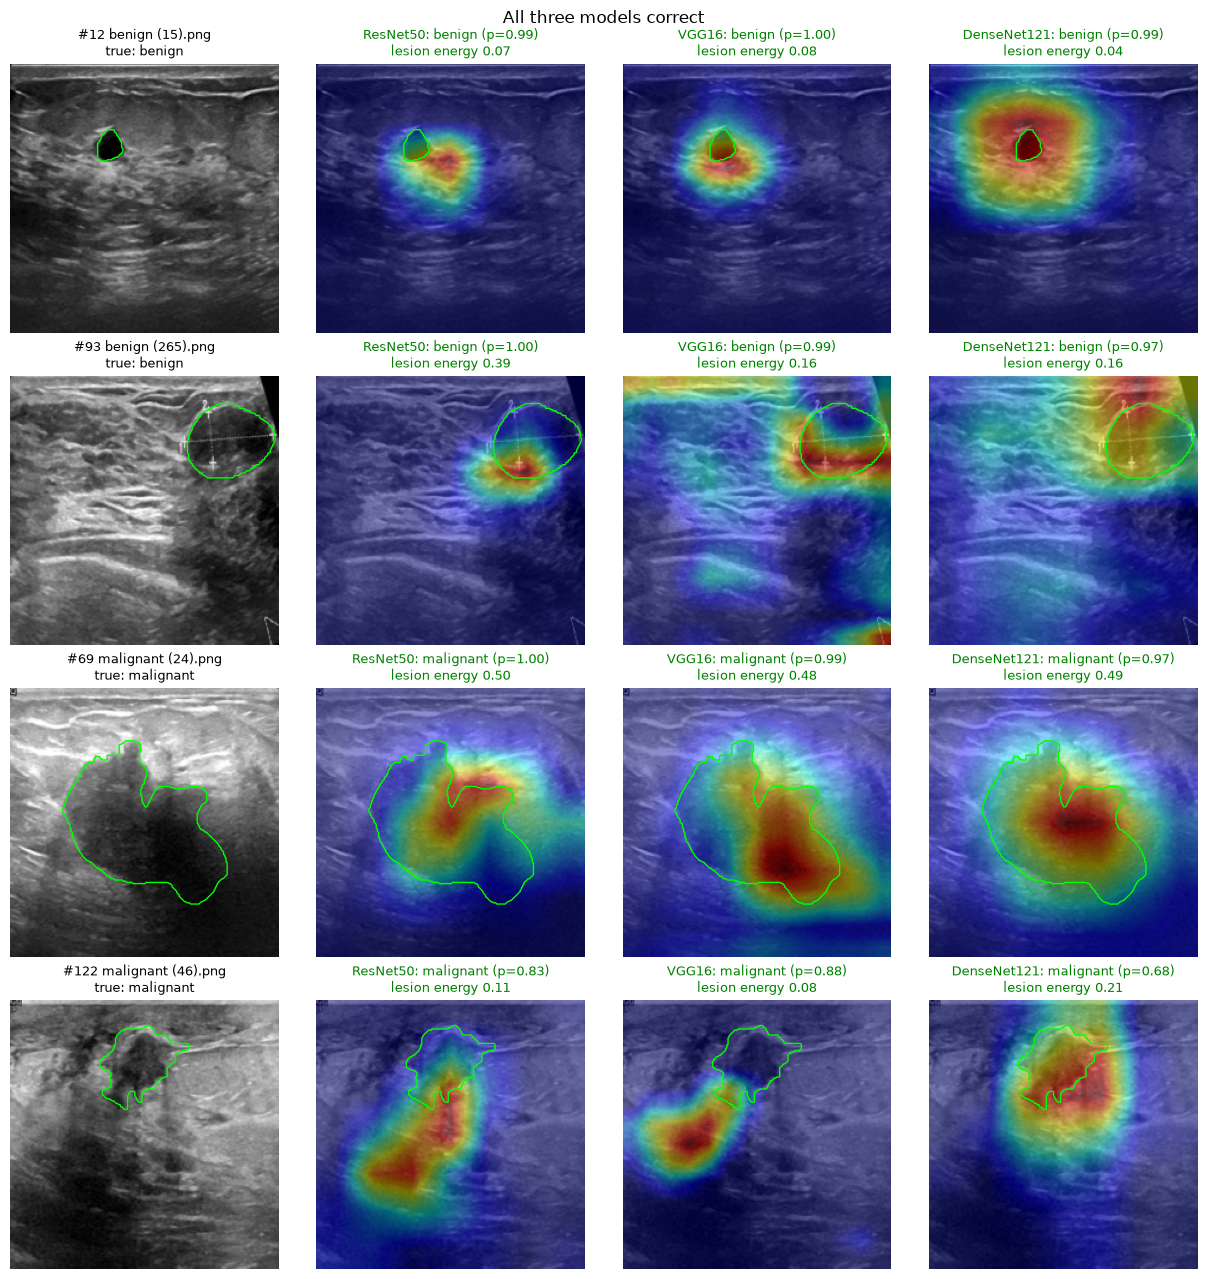

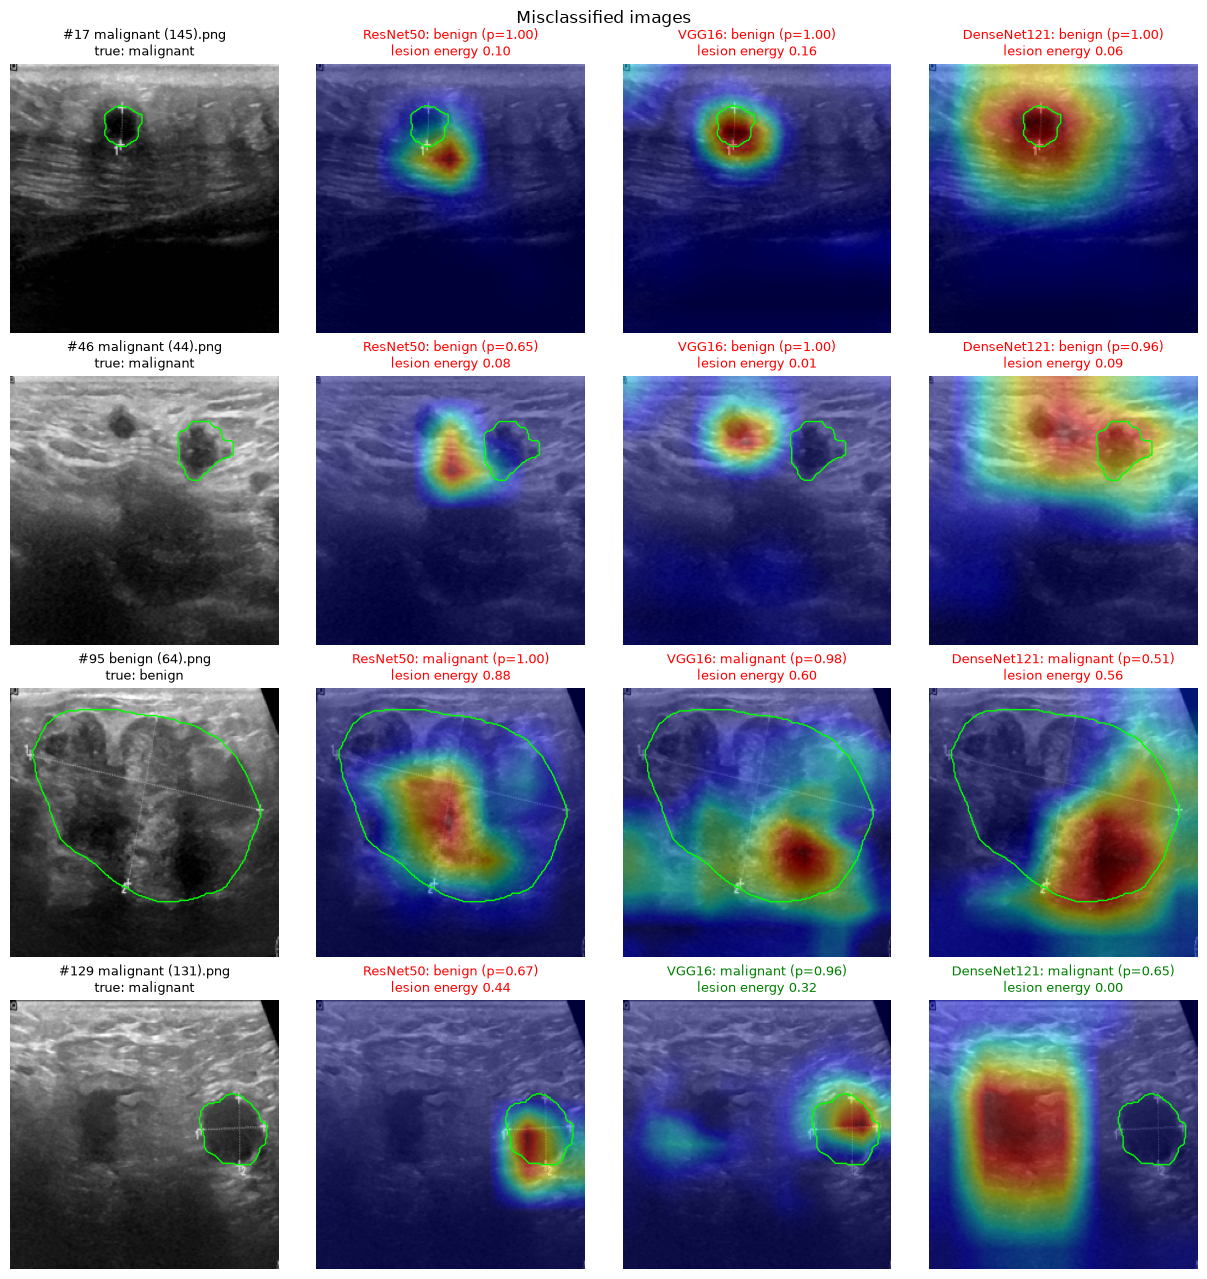

In [11]:
def comparison_figure(indices, title, path):
    fig, axes = plt.subplots(len(indices), 1 + len(names), figsize=(3.1 * (1 + len(names)), 3.25 * len(indices)))
    axes = np.atleast_2d(axes)
    for r, idx in enumerate(indices):
        _, display, mask, label, fname = samples[idx]
        axes[r, 0].imshow(display)
        axes[r, 0].contour(mask, levels=[0.5], colors="lime", linewidths=1.0)
        axes[r, 0].set_title(f"#{idx} {fname}\ntrue: {CLASS_NAMES[label]}", fontsize=9)
        axes[r, 0].axis("off")
        for c, name in enumerate(names, start=1):
            s = stats[(stats.model == name) & (stats.idx == idx)].iloc[0]
            ax = axes[r, c]
            ax.imshow(display)
            ax.imshow(all_cams[name][idx].astype(np.float32), cmap="jet", alpha=0.45, vmin=0, vmax=1)
            ax.contour(mask, levels=[0.5], colors="lime", linewidths=1.0)
            ax.set_title(f"{name}: {s.pred} (p={s.prob_pred:.2f})\nlesion energy {s.lesion_energy:.2f}",
                         fontsize=9, color=("green" if s.correct else "red"))
            ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    fig.savefig(path, dpi=110, bbox_inches="tight")
    return fig


fig = comparison_figure(pick_correct, "All three models correct", os.path.join(OUTPUT_DIR, "comparison_all_correct.png"))
plt.show()
fig = comparison_figure(pick_wrong, "Misclassified images", os.path.join(OUTPUT_DIR, "comparison_wrong.png"))
plt.show()

## 11. Average CAM per model over all 130 test images

Averaging the normalized maps shows whether a model has a *systematic* spatial
preference (e.g. always firing near the top of the frame or the image border),
independent of any single image. The first panel is the average lesion mask, i.e. where
lesions actually tend to be.

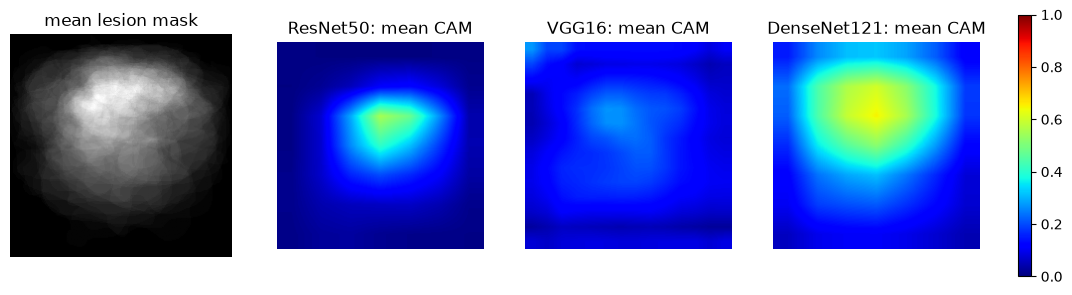

In [12]:
mean_mask = np.mean([s[2] for s in samples], axis=0)
fig, axes = plt.subplots(1, 1 + len(names), figsize=(3.3 * (1 + len(names)), 3.4))
axes[0].imshow(mean_mask, cmap="gray", vmin=0, vmax=mean_mask.max())
axes[0].set_title("mean lesion mask")
for ax, name in zip(axes[1:], names):
    im = ax.imshow(all_cams[name].astype(np.float32).mean(axis=0), cmap="jet", vmin=0, vmax=1)
    ax.set_title(f"{name}: mean CAM")
for ax in axes:
    ax.axis("off")
fig.colorbar(im, ax=axes[1:].tolist(), fraction=0.02)
fig.savefig(os.path.join(OUTPUT_DIR, "mean_cam_per_model.png"), dpi=110, bbox_inches="tight")
plt.show()